# Phase-burst coupling

The phase-burst coupling (PBC) measure compares the entropy of this distribution with that of the uniform distribution and reflects the degree to which bursts cluster at particular phases of the beta wave.

$$
PBC(t) = \frac{H_U – H_{PB}(t)}{H_U},
$$

where $H = -\sum_k p_k \ln p_k$ is entropy, $H_U$ denotes entropy of the uniform distribution, and $H_{PB}(t)$ denotes entropy of the phase-burst distribution at time $t$.

In [1]:
import sys, os
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

from burst_toolbox.coupling import compute_phase_burst_counts, phase_burst_coupling

## PBC on synthetic data

In this example, we position high gamma (30 ms) bursts at random peaks of 16-Hz beta waves over 100 trials and compare the resulting PBC with the case of random burst positioning.

In [ ]:
# Generate 100 16-Hz beta waves with random phase shifts
freq = 16
n_trials = 100

t = np.arange(0, 6500)

# Generate trials
random_state = np.random.RandomState(123)

# Phase shift
random_phase_shfit = np.zeros(n_trials)
random_phase_shfit = random_state.uniform(-np.pi, np.pi, n_trials)

beta_trace = np.array([np.cos(2 * np.pi * freq * t / 1000 + random_phase_shfit[trial_idx]) for trial_idx in range(n_trials)])
beta_trace.shape

(100, 6500)

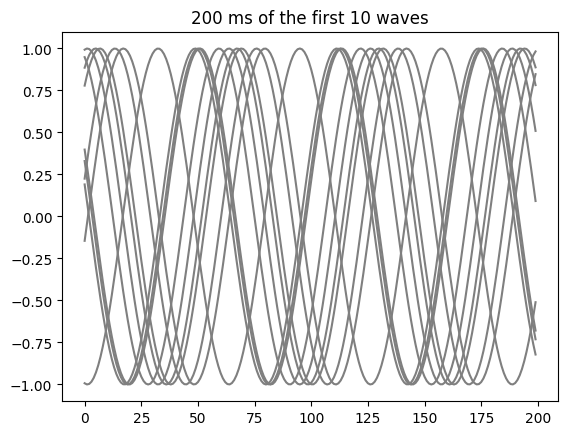

In [11]:
# Plot the first 10 waves
plt.plot(beta_trace[:10, :200].T, color = "tab:gray")
plt.title("200 ms of the first 10 waves");

We compare burst positioning over 15 random peaks vs 15 random angles.

In [47]:
burst_duration = 30 # (ms)
n_bursts = 15
bursts = np.zeros((2, n_trials, 6500)) # (peaks vs random, n_trials, time)

random_state = np.random.RandomState(123)

for trial_idx in range(n_trials):

    # Get random peak positions
    peaks = np.where(beta_trace[trial_idx, :] > 0.99)[0]
    peaks = random_state.choice(peaks, n_bursts, replace = False)

    # Get random angle positions
    rand_positions = random_state.randint(low = burst_duration + 10, high = 6500 - burst_duration - 10, size = n_bursts)

    for burst_id in range(len(peaks)):
        duration = random_state.normal(burst_duration, 1)
        bursts[0, trial_idx, int(peaks[burst_id] - duration / 2) : int(peaks[burst_id] + duration / 2)] = 1
        bursts[1, trial_idx, int(rand_positions[burst_id] - duration / 2) : int(rand_positions[burst_id] + duration / 2)] = 1

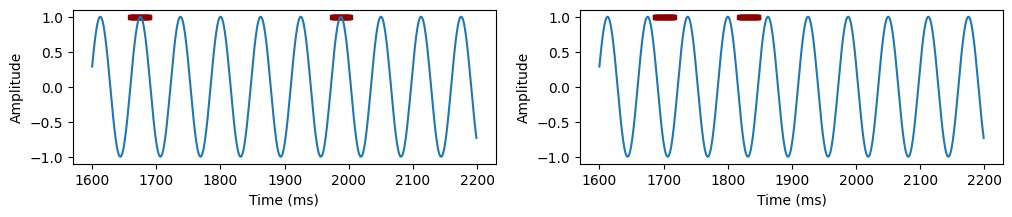

In [49]:
time_period = (1600, 2200)

fig, ax = plt.subplots(1, 2, figsize = (12, 2))

for col_id, title in enumerate(["Random peaks", "Random"]):
    ca = ax[col_id]
    ca.plot(range(time_period[0], time_period[1]), beta_trace[0, time_period[0] : time_period[1]])

    bursts_to_plot = bursts[col_id, 0, time_period[0] : time_period[1]]
    bursts_to_plot[bursts_to_plot == 0] = np.nan
    ca.scatter(range(time_period[0], time_period[1]), bursts_to_plot, marker = "s", s = 10, color = 'darkred')

    ca.set_xlabel("Time (ms)")
    ca.set_ylabel("Amplitude")
    ca.set_title

Next, we compute per-trial phase-burst counts and estimate PBC.

In [ ]:
res = []

for burst_type_idx, burst_type_name in enumerate(["Random peaks", "Random"]):
    # Compute PBC
    phase_burst_counts = compute_phase_burst_counts(
        LFP = beta_trace, 
        bursts = bursts[burst_type_idx], 
        filter = False, 
        phase_freq_band = np.array([12, 30]))
    pbc, phase_dist = phase_burst_coupling(phase_burst_counts)
    print(f"{burst_type_name}: avg PBC = {np.nanmean(pbc)}")

    # Normalize distribution
    distr = np.nanmean(phase_dist, axis = 0)
    distr = distr / np.sum(distr)

    res.append((pbc, distr))

Random peaks: avg PBC = 0.2269254215113466
Random: avg PBC = 0.006267093051754572


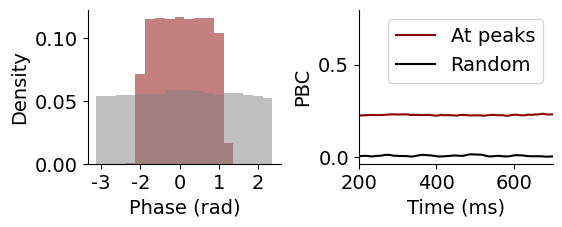

In [ ]:
plt.rcParams.update({"font.size": 14})
edge_labels = np.round(np.deg2rad(np.array([-180 + d * 20 for d in range(18)]))).astype(int)

fig, ax = plt.subplots(1, 2, figsize = (6, 2))
ca = ax[0]

ca.bar(range(0, 5 * 18, 5), res[0][1], width = 5, color = 'darkred', alpha = 0.5)
ca.bar(range(0, 5 * 18, 5), res[1][1], width = 5, color = 'gray', alpha = 0.5)
ca.set_xticks(range(0, 5 * 18, 5)[::4])
ca.set_xticklabels(edge_labels[::4])
ca.set_xlabel("Phase (rad)")
ca.set_ylabel("Density")
ca.spines[["top", "right"]].set_visible(False)

ca = ax[1]
ca.plot(t, res[0][0], color = 'darkred', label = "At peaks")
ca.plot(t, res[1][0], color = 'black', label = "Random")
ca.set_xlim(200, 700)

ca.set_xlabel("Time (ms)")
ca.set_ylabel("PBC")
ca.spines[["top", "right"]].set_visible(False)
ca.legend()

plt.subplots_adjust(wspace = 0.4)

## PBC on sample data

In this example, we compute PBC between beta (12-30 Hz) wave in LMFG and high gamma (70-140 Hz) bursts in the hippocampus.

In [2]:
data = pd.read_csv(os.path.join("sample_data", "MU16.csv"))
data.head()

,patient,region,channel,trial_idx,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,...,LFP_6489,LFP_6490,LFP_6491,LFP_6492,LFP_6493,LFP_6494,LFP_6495,LFP_6496,LFP_6497,LFP_6498
0,MU16,LMFG,47,2,-60.586345,-61.003159,-56.932662,-49.502180,-57.041221,-50.611589,...,-22.416510,-19.159159,-31.267181,-24.738918,-36.600229,-32.127004,-28.065220,-26.732139,-31.661379,-21.543727
1,MU16,LMFG,47,3,70.637892,70.961432,60.612772,64.904897,61.675591,56.262496,...,-75.301535,-67.050140,-66.253000,-57.827647,-60.655502,-66.283112,-49.654750,-36.654182,-44.326227,-47.930041
2,MU16,LMFG,47,4,106.745603,95.213250,102.347220,94.459910,102.302446,93.481191,...,-3.919453,1.671527,3.907104,5.109215,4.066670,-6.005560,-9.228409,-4.949366,-10.088047,-11.581020
3,MU16,LMFG,47,5,-141.957212,-142.918853,-151.615530,-139.499856,-139.383692,-137.511779,...,-105.997811,-109.009809,-106.829899,-117.390465,-115.232323,-109.082471,-119.630475,-115.983875,-129.566979,-127.320677
4,MU16,LMFG,47,6,26.043050,41.416215,35.086903,36.075132,38.714519,39.923637,...,-78.135456,-80.281772,-72.660984,-69.412884,-61.186371,-61.112856,-64.577571,-58.155731,-60.150052,-54.026011


In [3]:
print(f"ROIs and channels:")
data[['region', 'channel']].drop_duplicates(ignore_index = True)

ROIs and channels:


,region,channel
0,LMFG,47
1,LMFG,60
2,LH,2
3,LH,10


Note that unlike previous analysis, we have to be careful about matching trials across channels.

In [9]:
from burst_toolbox.dsp import compute_power
from burst_toolbox.bursts import detect_bursts
from burst_toolbox.stats import cluster_test_period

LFP_COLS = [f"LFP_{k}" for k in range(6499)]
BURST_COLS = [f"burst_{k}" for k in range(6499)]
BASELINE = np.array([100, 900])

bursts = []
for channel in [2, 10]:

    # Compute trial-by-trial power in the burst frequency band
    tbt_power = compute_power(
        LFP = data[data["channel"] == channel][LFP_COLS].to_numpy(),
        freq_band = np.array([70, 140])
        )

    # Detect bursts
    detected_bursts = detect_bursts(
        power = tbt_power,
        reference_period = BASELINE,
        min_dur_ms = 3 * 1000 / np.mean(np.array([70, 140])) # Duration threshold is based on the mean frequency over the burst freq. band
    )

    detected_bursts = pd.DataFrame(detected_bursts)
    detected_bursts.columns = BURST_COLS
    detected_bursts["channel"] = channel
    detected_bursts["trial_idx"] = data[data["channel"] == channel]["trial_idx"].to_numpy()

    bursts.append(detected_bursts)

bursts = pd.concat(bursts, ignore_index = True)
bursts.head()

,burst_0,burst_1,burst_2,burst_3,burst_4,burst_5,burst_6,burst_7,burst_8,burst_9,...,burst_6491,burst_6492,burst_6493,burst_6494,burst_6495,burst_6496,burst_6497,burst_6498,channel,trial_idx
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,5


In [ ]:
pbc_estimates = []

for channel_LMFG in [47, 60]:
    for channel_LH in [2, 10]:

        # Match trials
        channel1_trials = set(data[data["channel"] == channel_LMFG]["trial_idx"])
        channel2_trials = set(bursts[bursts["channel"] == channel_LH]["trial_idx"])
        common_trials = channel1_trials.intersection(channel2_trials)

        channel1_LFP = data[(data["channel"] == channel_LMFG) & (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[LFP_COLS].to_numpy()
        channel2_bursts = bursts[(bursts["channel"] == channel_LH) & (bursts["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[BURST_COLS].to_numpy()
        assert(channel1_LFP.shape == channel2_bursts.shape)

        # Compute PBC
        phase_burst_counts = compute_phase_burst_counts(
            LFP = channel1_LFP,
            bursts = channel2_bursts,
            filter = True,
            phase_freq_band = np.array([12, 30])
            )

        pbc, _ = phase_burst_coupling(phase_burst_counts)
        pbc_estimates.append(pbc)

pbc_estimates = np.stack(pbc_estimates)
pbc_estimates.shape

(4, 6499)

/Users/vladimiromelyusik/Burst-Toolbox/examples/../burst_toolbox/stats.py:155: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)


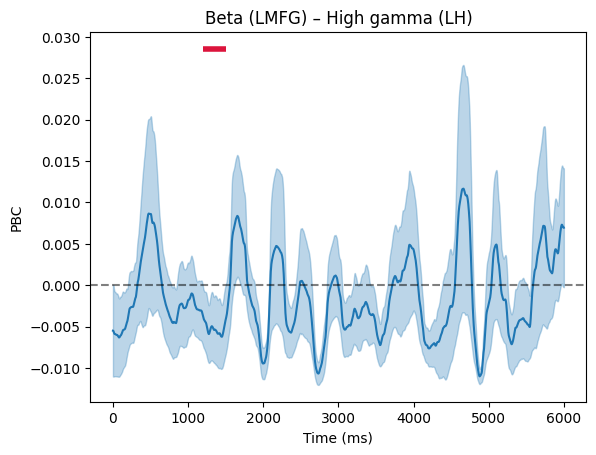

In [12]:
fig, ax = plt.subplots(1, 1)
ca = ax

cutoff = 6000 # (ms)

# Baseline-correct
pbc_estimates = pbc_estimates - np.nanmean(pbc_estimates[:, BASELINE[0] : BASELINE[1]])
pbc_estimates = pbc_estimates[:, :cutoff]

avg_pbc = np.nanmean(pbc_estimates, axis = 0)
sem_pbc = np.nanstd(pbc_estimates, axis = 0) / np.sqrt(len(pbc_estimates))
T = len(avg_pbc)

ca.plot(
    range(T), 
    uniform_filter1d(avg_pbc, 200),
    color = "tab:blue"
    )
ca.fill_between(
    range(T), 
    uniform_filter1d(avg_pbc - sem_pbc, 200), 
    uniform_filter1d(avg_pbc + sem_pbc, 200),
    color = "tab:blue",
    alpha = 0.3
    )

ca.set_xlabel("Time (ms)")
ca.set_ylabel("PBC")
ca.set_title("Beta (LMFG) – High gamma (LH)")
ca.axhline(0, ls = "--", color = "black", alpha = 0.5)

# Cluster-test
step = 100
win_range = np.arange(0, len(LFP_COLS), step)
clusters = cluster_test_period(
    sample = pbc_estimates,
    period = BASELINE,
    win_range = win_range,
    win_size = 200
)

if len(clusters) > 0:
    yval = ca.get_ylim()[1]
    for tstat_id, period in enumerate(win_range):
        if (period < 100) or (period > 6200): continue
        if clusters[tstat_id] == 0: continue
        ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)